In [1]:
from torchvision.datasets import FashionMNIST
import torchvision
from torchvision.transforms import v2
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DECICE USED:", device)

train_tf = v2.Compose([
    v2.RandomCrop(28, padding=2),
    v2.RandomHorizontalFlip(),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.2860,), (0.3530,)),
    v2.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])

test_tf = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.2860,), (0.3530,)),
])

train_data = FashionMNIST(root="data", train=True, download=True,
                        transform=train_tf,
                        target_transform=None)
test_data = FashionMNIST(root="data", train=False, download=True,
                        transform=test_tf,
                        target_transform=None)

DECICE USED: cuda


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.2MB/s]


Image shape: torch.Size([1, 28, 28])


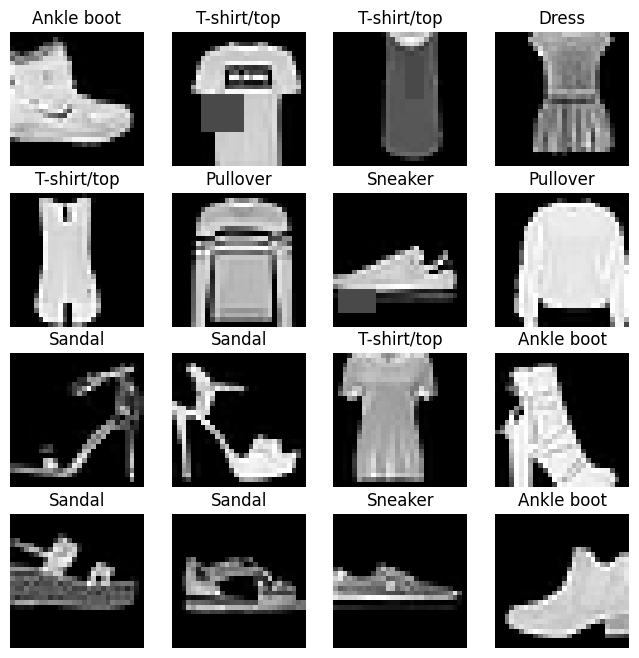

In [2]:
import matplotlib.pyplot as plt

print("Image shape:", train_data[0][0].shape)

class_names = train_data.classes
fig, ax = plt.subplots(4,4,figsize=(8,8))
k = 0
for i in range(4):
    for j in range(4):
        image, label = train_data[k]
        ax[i, j].imshow(image.squeeze(), cmap='grey')
        ax[i,j].axis(False)
        ax[i,j].set_title(class_names[int(label)])
        k += 1

In [3]:
from torch.utils.data import DataLoader
import torch
torch.manual_seed(152)
BATCH_SIZE = 128
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

In [4]:
from sklearn.metrics import accuracy_score

def train_step(model: torch.nn.Module, data_loader, loss_fn, optimizer,):
     loss_total = 0
     acc_total = 0
     model.train()
     for X, y in data_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss_total += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
     loss_total /= len(data_loader)
     acc_total /= len(data_loader)
     return {"Loss": loss_total.item(), "Acc": acc_total}

def test_step(model: torch.nn.Module, data_loader, loss_fn):
    loss_total = 0
    acc_total = 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            loss_total += loss
            acc_total += accuracy_score(y.cpu(), y_pred.cpu().argmax(dim=1))
        loss_total /= len(data_loader)
        acc_total /= len(data_loader)
        return {"Loss": loss_total.item(), "Acc": acc_total}

#BASIC MODEL

In [5]:
from torch import nn
from torchvision import transforms

class ConvBlock(nn.Module):
  def __init__(self, input_shape, hidden_units):
    """
    Passes X through two conv layer, batch, Relu, twice and ends with maxPool
    """
    super().__init__()
    self.conv_block = nn.Sequential(
                nn.Conv2d(in_channels=input_shape,
                            out_channels=hidden_units,
                            kernel_size=3,
                            stride=1,
                            padding=1),
                nn.BatchNorm2d(num_features=hidden_units),
                nn.ReLU(),
                nn.Conv2d(in_channels=hidden_units,
                            out_channels=hidden_units,
                            kernel_size=3,
                            stride=1,
                            padding=1),
                nn.BatchNorm2d(num_features=hidden_units),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2))

  def forward(self, x):
    return self.conv_block(x)

class ConvClassifier(nn.Module):
  #Flattens and classifies conv layer output
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(in_features=input_shape,
                          out_features=hidden_units),
                nn.Dropout(p=0.2),
                nn.Linear(in_features=hidden_units,
                          out_features=output_shape))
    def forward(self, x):
        return self.classifier(x)

class FashionClassifier(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.conv_block_1 = ConvBlock(input_shape=input_shape, hidden_units=hidden_units)
        self.conv_block_2 = ConvBlock(input_shape=hidden_units, hidden_units=hidden_units*2)
        self.classifier_layer = ConvClassifier(input_shape=hidden_units*2*7*7, hidden_units=32, output_shape=output_shape)

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier_layer(x)
        return x


In [6]:
model = FashionClassifier(input_shape=1, hidden_units=10, output_shape=len(class_names)).to(device)

In [7]:
from tqdm import tqdm

epochs = 30
optimizer = torch.optim.AdamW(params=model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
train_loss_list = list()
test_loss_list = list()

for epoch in tqdm(range(epochs)):
    res_train = train_step(model=model,
                           data_loader=train_dataloader,
                           loss_fn=loss_fn,
                           optimizer=optimizer)
    train_loss_list.append(res_train['Loss'])
    res_test = test_step(model=model,
                           data_loader=test_dataloader,
                           loss_fn=loss_fn)
    test_loss_list.append(res_test['Loss'])
    print(f"EPOCH: {epoch} \n TRAIN Loss: {res_train['Loss']} \n TEST Loss: {res_test['Loss']}\n TEST Acc: {res_test['Acc']*100:.2f}%")

  3%|▎         | 1/30 [00:40<19:46, 40.93s/it]

EPOCH: 0 
 TRAIN Loss: 0.6531099081039429 
 TEST Loss: 0.42242205142974854
 TEST Acc: 84.56%


  7%|▋         | 2/30 [01:20<18:42, 40.10s/it]

EPOCH: 1 
 TRAIN Loss: 0.45367175340652466 
 TEST Loss: 0.4334609806537628
 TEST Acc: 84.04%


 10%|█         | 3/30 [01:58<17:39, 39.24s/it]

...

EPOCH: 27 
 TRAIN Loss: 0.26139259338378906 
 TEST Loss: 0.24819688498973846
 TEST Acc: 91.11%


 97%|█████████▋| 29/30 [18:54<00:38, 38.83s/it]

EPOCH: 28 
 TRAIN Loss: 0.2608891725540161 
 TEST Loss: 0.2609114944934845
 TEST Acc: 90.75%


100%|██████████| 30/30 [19:36<00:00, 39.20s/it]

EPOCH: 29 
 TRAIN Loss: 0.26200124621391296 
 TEST Loss: 0.22837664186954498
 TEST Acc: 91.68%


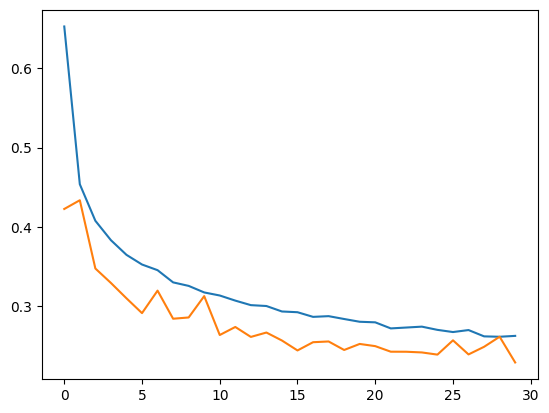

In [8]:
fig, ax = plt.subplots()
ax.plot(train_loss_list)
ax.plot(test_loss_list)